In [1]:
import networkx as nx
import numpy as np
import torch
from src.dataset import NIMDatasetHandler
from torch import nn

import decent_bench.algorithms.decentralized as dec_algorithms
import decent_bench.utils.interoperability as iop
from decent_bench import benchmark
from decent_bench.agents import Agent
from decent_bench.algorithms.utils import pytorch_initialization
from decent_bench.costs import PyTorchCost
from decent_bench.metrics import metric_library as ml
from decent_bench.metrics import runtime_library
from decent_bench.networks import P2PNetwork
from decent_bench.utils.pytorch_utils import SimpleLinearModel
from decent_bench.utils.types import SupportedDevices
from examples.nim.src.algorithms.lt_admm_ema import LT_ADMM_EMA
from examples.nim.src.algorithms.lt_admm_torch_optimizer import LT_ADMM_TORCH


In [ ]:
train_dataset = NIMDatasetHandler(
    image_file="data/kth_floorplan.png",
    n_partitions=5,
    samples_per_partition=20,
    transform=torch.tensor,
    label_transform=lambda x: torch.tensor(x, dtype=torch.float32).unsqueeze(
        0
    ),  # Convert to tensor and add batch dimension
    label_balance=2.0,
    leakage=0.1,
)
display(train_dataset.get_partitions()[0])


def model_generator() -> torch.nn.Module:
    """Generate a simple linear model for the NIM dataset."""
    return SimpleLinearModel(
        input_size=2,
        hidden_sizes=[32, 16],
        output_size=1,
    )


class FinalActivation(nn.Module):  # noqa: D101
    def __init__(self, threshold: float = 0.5):
        super().__init__()
        self.sigmoid = nn.Sigmoid()
        self.threshold = threshold

    def forward(self, x: torch.Tensor) -> torch.Tensor:  # noqa: D102
        return (self.sigmoid(x) > self.threshold).long()


cost = PyTorchCost(
    dataset=train_dataset.get_partitions()[0],
    model=model_generator(),
    loss_fn=nn.BCEWithLogitsLoss(),
    final_activation=FinalActivation(threshold=0.5),
    batch_size=4,
    max_batch_size=4,
    device=SupportedDevices.CPU,
)

[(tensor([0.1921, 0.2454]), tensor([0.])),
 (tensor([0.1829, 0.6042]), tensor([0.])),
 (tensor([0.0130, 0.0156]), tensor([0.])),
 (tensor([0.1667, 0.5521]), tensor([0.])),
 (tensor([0.0189, 0.0794]), tensor([0.])),
 (tensor([0.0286, 0.0280]), tensor([0.])),
 (tensor([0.2083, 0.5977]), tensor([0.])),
 (tensor([0.0156, 0.1400]), tensor([0.])),
 (tensor([0.1927, 0.0124]), tensor([0.])),
 (tensor([0.0221, 0.5039]), tensor([0.])),
 (tensor([0.1556, 0.0716]), tensor([1.])),
 (tensor([0.1107, 0.2051]), tensor([1.])),
 (tensor([0.0742, 0.4993]), tensor([1.])),
 (tensor([0.1172, 0.5384]), tensor([1.])),
 (tensor([0.0827, 0.6087]), tensor([1.])),
 (tensor([0.0560, 0.0827]), tensor([1.])),
 (tensor([0.0618, 0.2109]), tensor([1.])),
 (tensor([0.1315, 0.2174]), tensor([1.])),
 (tensor([0.1322, 0.4831]), tensor([1.])),
 (tensor([0.1582, 0.5111]), tensor([1.]))]

In [ ]:
def split_dataset(data):
    """
    Split dataset into features and labels.

    Args:
        data: dataset to split, as a tuple of (features, labels)

    Returns:
        tuple of (features, labels)

    """
    x, y = zip(*data, strict=True)
    test_x = tuple(x)
    test_y = np.array(y)
    return test_x, test_y


test_x, _ = split_dataset(train_dataset.get_test_set())

In [7]:
display(test_x[:5])
display(_[:5])

(tensor([0., 0.]),
 tensor([0.0007, 0.0000]),
 tensor([0.0013, 0.0000]),
 tensor([0.0020, 0.0000]),
 tensor([0.0026, 0.0000]))

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.]], dtype=float32)

In [8]:
cost.predict(cost._get_model_parameters(), list(test_x))

[[1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1]

In [2]:
iterations = 100  # 10_000
state_snapshot_period = 5
samples_per_partition = 2000
leakage = 0.0
label_balance = 2.0
image_file = "data/kth_floorplan.png"
batch_size = 32
local_steps = [5, 10]
device = SupportedDevices.CPU
opt_cls = torch.optim.Adam

table_metrics = [
    ml.ConsensusError([min, np.average, max]),
    ml.GradientCalls([np.average, sum]),
    ml.SentMessages([np.average, sum]),
    ml.MSE([min, np.average, max]),
    ml.Loss([min, np.average, max]),
]

plot_metrics = [
    [ml.ConsensusError([], x_log=False, y_log=True)],
    [ml.MSE([], x_log=False, y_log=True)],
    [ml.Loss([], x_log=False, y_log=False)],
]


def model_generator() -> torch.nn.Module:
    """Generate a simple linear model for the NIM dataset."""
    return SimpleLinearModel(
        input_size=2,
        hidden_sizes=[32, 16],
        output_size=1,
    )


class FinalActivation(nn.Module):  # noqa: D101
    def __init__(self, threshold: float = 0.5):
        super().__init__()
        self.sigmoid = nn.Sigmoid()
        self.threshold = threshold

    def forward(self, x: torch.Tensor) -> torch.Tensor:  # noqa: D102
        return (self.sigmoid(x) > self.threshold).long()


iop.set_seed(47)
train_dataset = NIMDatasetHandler(
    image_file=image_file,
    n_partitions=5,
    samples_per_partition=samples_per_partition,
    transform=torch.tensor,  # type: ignore[arg-type]
    label_transform=lambda x: torch.tensor(x, dtype=torch.float32).unsqueeze(0),  # type: ignore[arg-type]
    label_balance=label_balance,
    leakage=leakage,
)
costs = [
    PyTorchCost(
        dataset=p,
        model=model_generator(),
        loss_fn=nn.BCEWithLogitsLoss(),
        final_activation=FinalActivation(threshold=0.5),
        batch_size=batch_size,
        max_batch_size=batch_size * 4,
        device=device,
    )
    for p in train_dataset.get_partitions()
]
agents = [
    Agent(
        i,
        cost,
        state_snapshot_period=state_snapshot_period,
    )
    for i, cost in enumerate(costs)
]
graph = nx.random_regular_graph(d=4, n=5, seed=iop.get_seed())
network = P2PNetwork(
    graph=graph,
    agents=agents,
)
problem = benchmark.BenchmarkProblem(
    network=network,
    test_data=train_dataset.get_test_set(1.0, 10000),
)
x0 = pytorch_initialization(network, all_same=True)
algorithms = [
    dec_algorithms.DGD(
        step_size=0.1,
        aux_step_size=1.0,
        iterations=iterations,
        x0=x0,
    ),
    dec_algorithms.KGT(
        iterations=iterations,
        local_steps=10,
        step_size=0.01,
        aux_step_size=0.5,
        x0=x0,
    ),
    dec_algorithms.ProxSkip(
        iterations=iterations,
        step_size=0.1,
        aux_step_size=0.1,
        comm_probability=1.0 / 10,
        chi=1.0,
        x0=x0,
    ),
    dec_algorithms.LED(
        iterations=iterations,
        local_steps=10,
        step_size=0.01,
        aux_step_size=0.01,
        x0=x0,
    ),
    dec_algorithms.LT_ADMM(
        iterations=iterations,
        local_steps=10,
        step_size=0.01,
        aux_step_size=0.01,
        penalty=1.0,
        x0=x0,
    ),
    LT_ADMM_TORCH(
        iterations=iterations,
        local_steps=10,
        step_size=0.001,
        aux_step_size=0.01,
        penalty=1.0,
        x0=x0,
        opt_cls=opt_cls,
    ),
    dec_algorithms.LT_ADMM_VR(
        iterations=iterations,
        local_steps=10,
        step_size=0.01,
        aux_step_size=0.01,
        penalty=1.0,
        x0=x0,
    ),
    LT_ADMM_EMA(
        iterations=iterations,
        local_steps=10,
        step_size=0.005,
        aux_step_size=0.01,
        penalty=1.0,
        ema_factor=0.8,
        send_ema_x=False,
        use_z_ema=False,
        x0=x0,
    ),
    LT_ADMM_EMA(
        iterations=iterations,
        local_steps=10,
        step_size=0.0005,
        aux_step_size=0.01,
        penalty=1.0,
        ema_factor=0.8,
        send_ema_x=False,
        use_z_ema=False,
        x0=x0,
        opt_cls=opt_cls,
    ),
]

algorithms = sorted(algorithms, key=lambda alg: alg.name)

result = benchmark.benchmark(
    algorithms=algorithms,
    benchmark_problem=problem,
    n_trials=1,
    show_speed=True,
    show_trial=True,
    runtime_metrics=[
        runtime_library.RuntimeLoss(10),
    ],
)


metric_result = benchmark.compute_metrics(
    benchmark_result=result,
    table_metrics=table_metrics,
    plot_metrics=plot_metrics,
)

benchmark.display_metrics(
    metrics_result=metric_result,
    show_plots=False,
)

[04/07/26 04:58:29] INFO     No checkpoint manager provided, running benchmark without            ]8;id=543169;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py\_benchmark.py]8;;\:]8;id=579410;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py#267\267]8;;\
                             checkpointing. Progress cannot be resumed if interrupted.                             

                    INFO     Starting benchmark execution                                         ]8;id=35357;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py\_benchmark.py]8;;\:]8;id=293371;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py#353\353]8;;\

Output()

[04/07/26 04:59:15] INFO     Benchmark execution complete, thanks for using decent-bench          ]8;id=215197;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py\_benchmark.py]8;;\:]8;id=985421;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py#371\371]8;;\

Output()

Output()

[04/07/26 05:00:01] INFO     Empirical-risk cost functions are in use. Compute counters increment by  ]8;id=313153;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=704101;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#67\67]8;;\
                             the number of samples processed in each method call, which can lead to                
                             large raw counts. Applying scaling factor of 'scale_compute=1.0' to ['nr              
                             gradient calls'] metrics for display.                                                 

                    INFO                                                                              ]8;id=892552;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=873240;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#98\98]8;;\
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+---------------------+---------------------+-------              
                             --------------+---------------------+---------------------+-------------              
                             --------+                                                                             
                             | Metric (statistic)      | DGD                 | K-GT                |               
                             LED                 | LT-ADMM             | LT-ADMM-EMA         |                     
                             LT-ADMM-EMA         | LT-ADMM-TORCH       | LT-ADMM-VR          |                     
                             ProxSkip            |                                                                 
                             +=========================+=====================+=====================+=              
                             ====================+=====================+=====================+=======              
                             ==============+=====================+=====================+=============              
                             ========+                                                                             
                             | consensus error (min)   | 7.35e-03 ± 0.00e+00 | 1.39e-07 ± 0.00e+00 |               
                             1.14e-07 ± 0.00e+00 | 1.43e-03 ± 0.00e+00 | 2.17e-04 ± 0.00e+00 |                     
                             5.57e-03 ± 0.00e+00 | 3.61e-02 ± 0.00e+00 | 5.88e-05 ± 0.00e+00 |                     
                             3.58e-02 ± 0.00e+00 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+---------------------+---------------------+-------              
                             --------------+---------------------+---------------------+-------------              
                             --------+                                                                             
                             | consensus error (avg)   | 1.14e-02 ± 0.00e+00 | 1.50e-07 ± 0.00e+00 |               
                             1.49e-07 ± 0.00e+00 | 2.39e-03 ± 0.00e+00 | 9.47e-04 ± 0.00e+00 |                     
                             9.22e-03 ± 0.00e+00 | 5.88e-02 ± 0.00e+00 | 8.72e-05 ± 0.00e+00 |                     
                             1.02e-01 ± 0.00e+00 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+---------------------+---------------------+-------              
                             --------------+---------------------+---------------------+-------------              
                             --------+                                                                             
                             | consensus error (max)   | 1.98e-02 ± 0.00e+00 | 1.69e-07 ± 0.00e+00 |               
                             1.84e-07 ± 0.00e+00 | 4.09e-03 ± 0.00e+00 | 1.72e-03 ± 0.00e+00 |                     
                             1.28e-02 ± 0.00e+00 | 9.27e-02 ± 0.00e+00 | 1.12e-04 ± 0.00e+00 |                     
                             1.44e-01 ± 0.00e+00 |                                               

[04/07/26 05:13:26] INFO     Empirical-risk cost functions are in use. Compute counters increment by  ]8;id=956508;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=103405;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#67\67]8;;\
                             the number of samples processed in each method call, which can lead to                
                             large raw counts. Applying scaling factor of 'scale_compute=1.0' to ['nr              
                             gradient calls'] metrics for display.                                                 

                    INFO                                                                              ]8;id=252863;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=818766;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#98\98]8;;\
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+---------------------+---------------------+-------              
                             --------------+---------------------+---------------------+-------------              
                             --------+                                                                             
                             | Metric (statistic)      | DGD                 | K-GT                |               
                             LED                 | LT-ADMM             | LT-ADMM-EMA         |                     
                             LT-ADMM-EMA         | LT-ADMM-TORCH       | LT-ADMM-VR          |                     
                             ProxSkip            |                                                                 
                             +=========================+=====================+=====================+=              
                             ====================+=====================+=====================+=======              
                             ==============+=====================+=====================+=============              
                             ========+                                                                             
                             | consensus error (min)   | 7.35e-03 ± 0.00e+00 | 1.39e-07 ± 0.00e+00 |               
                             1.14e-07 ± 0.00e+00 | 1.43e-03 ± 0.00e+00 | 2.17e-04 ± 0.00e+00 |                     
                             5.57e-03 ± 0.00e+00 | 3.61e-02 ± 0.00e+00 | 5.88e-05 ± 0.00e+00 |                     
                             3.58e-02 ± 0.00e+00 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+---------------------+---------------------+-------              
                             --------------+---------------------+---------------------+-------------              
                             --------+                                                                             
                             | consensus error (avg)   | 1.14e-02 ± 0.00e+00 | 1.50e-07 ± 0.00e+00 |               
                             1.49e-07 ± 0.00e+00 | 2.39e-03 ± 0.00e+00 | 9.47e-04 ± 0.00e+00 |                     
                             9.22e-03 ± 0.00e+00 | 5.88e-02 ± 0.00e+00 | 8.72e-05 ± 0.00e+00 |                     
                             1.02e-01 ± 0.00e+00 |                                                                 
                             +-------------------------+---------------------+---------------------+-              
                             --------------------+---------------------+---------------------+-------              
                             --------------+---------------------+---------------------+-------------              
                             --------+                                                                             
                             | consensus error (max)   | 1.98e-02 ± 0.00e+00 | 1.69e-07 ± 0.00e+00 |               
                             1.84e-07 ± 0.00e+00 | 4.09e-03 ± 0.00e+00 | 1.72e-03 ± 0.00e+00 |                     
                             1.28e-02 ± 0.00e+00 | 9.27e-02 ± 0.00e+00 | 1.12e-04 ± 0.00e+00 |                     
                             1.44e-01 ± 0.00e+00 |                                               

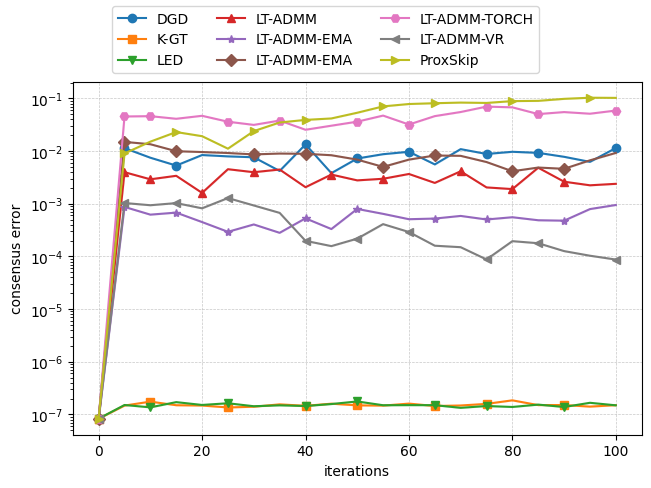

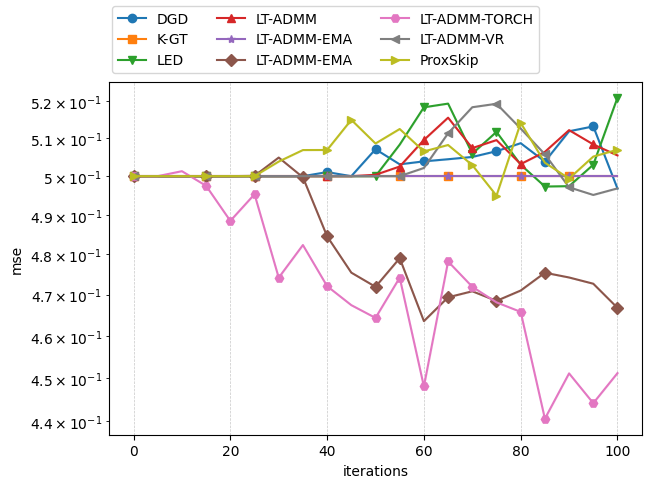

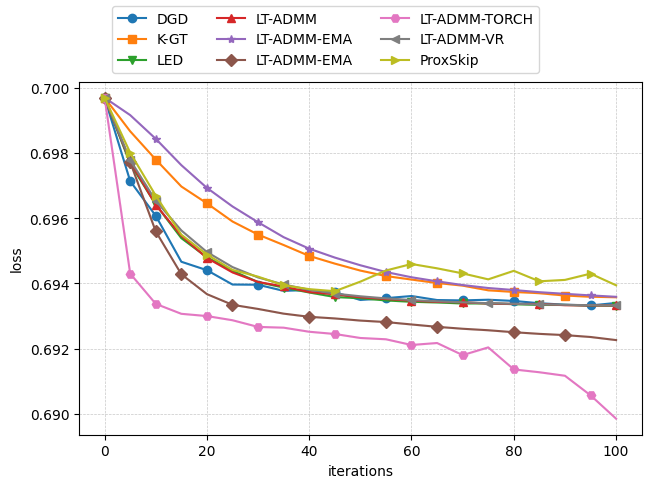

In [13]:
benchmark.display_metrics(
    metrics_result=metric_result,
    show_plots=True,
)

Results for DGD, 1 trials
0.5003395676612854 0.48475950956344604
0.5049604773521423 0.4895252287387848
0.4973137080669403 0.48112958669662476
0.506144106388092 0.49073347449302673
0.5057704448699951 0.49001917243003845


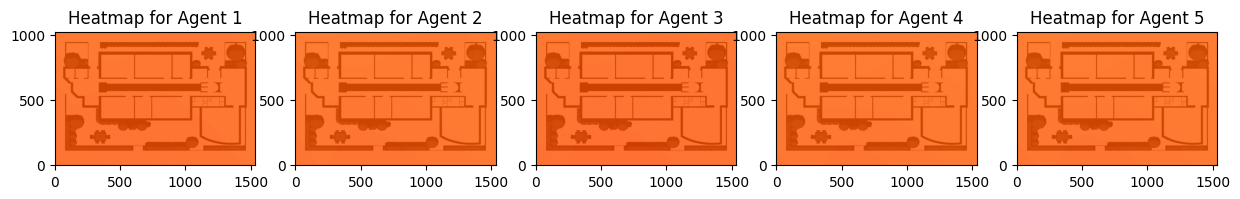

Results for K-GT, 1 trials
0.4983552098274231 0.48185667395591736


KeyboardInterrupt: 

In [11]:
import matplotlib.pyplot as plt
from PIL import Image

from decent_bench.networks import Network


def heatmap_plot(
    network: Network,
    width: int,
    height: int,
    norm: float,
) -> list[list[float]]:
    xs = np.arange(0, width) / norm
    ys = np.arange(0, height) / norm
    X, Y = np.meshgrid(xs, ys, indexing="xy")
    nx, ny = X.shape
    points = np.column_stack((X.ravel(), Y.ravel()))

    mats = []
    for agent in network.agents():
        agent_activation = agent.cost.final_activation
        agent.cost.final_activation = nn.Sigmoid()
        out = agent.cost.predict(agent.x, torch.tensor(points, dtype=torch.float32))
        agent.cost.final_activation = agent_activation
        out_np = np.array(out)
        print(out_np.max(), out_np.min())

        mats.append(out_np.reshape((nx, ny)))

    return mats


image = Image.open(image_file).convert("L")
image_array = np.array(image)

for alg, networks in result.states.items():
    print(f"Results for {alg.name}, {len(networks)} trials")
    for n in networks:
        heatmaps = heatmap_plot(n, train_dataset.width, train_dataset.height, train_dataset.feature_norm)

        fig, ax = plt.subplots(1, 5, figsize=(15, 10))
        for i, map in enumerate(heatmaps):
            ax[i].imshow(image_array, cmap="gray")
            ax[i].imshow(map, cmap="hot", interpolation="nearest", vmin=0, vmax=1, alpha=0.8)
            ax[i].invert_yaxis()
            ax[i].set_title(f"Heatmap for Agent {i + 1}")
        plt.show()